<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/WrittenReportChapter7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Bunderson - Written Report Ch 7

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex0727)

,Mass,Tcell
,<dbl>,<dbl>
1,3.33,0.252
2,4.62,0.263
3,5.43,0.251
4,5.73,0.251
5,6.12,0.183
6,6.29,0.213


#Introduction: Describe the Data and Present the Question
Sexual selection theory suggests that exaggerated physical displays may function as honest signals of male quality. In black wheatears (Oenanthe leucura), males engage in a striking display behavior by transporting large stones to nesting cavities. Although these birds weigh only about 35 grams, they carry an average of 3.1 kilograms of stones per breeding season. Researchers have hypothesized that the size of stones carried may reflect male health status, with larger stones potentially signaling stronger immune function. To investigate this hypothesis, M. Soler et al. recorded the average stone mass (in grams) transported by each of 21 male black wheatears and measured their T-cell response, an indicator of immune system strength. The primary research question is whether immune function, as measured by T-cell response, is associated with the average mass of stones carried. In this analysis, I examine the nature and strength of the relationship between these two quantitative variables and assess whether the data provide statistical evidence that healthier males carry heavier stones.

#Graphical Analysis

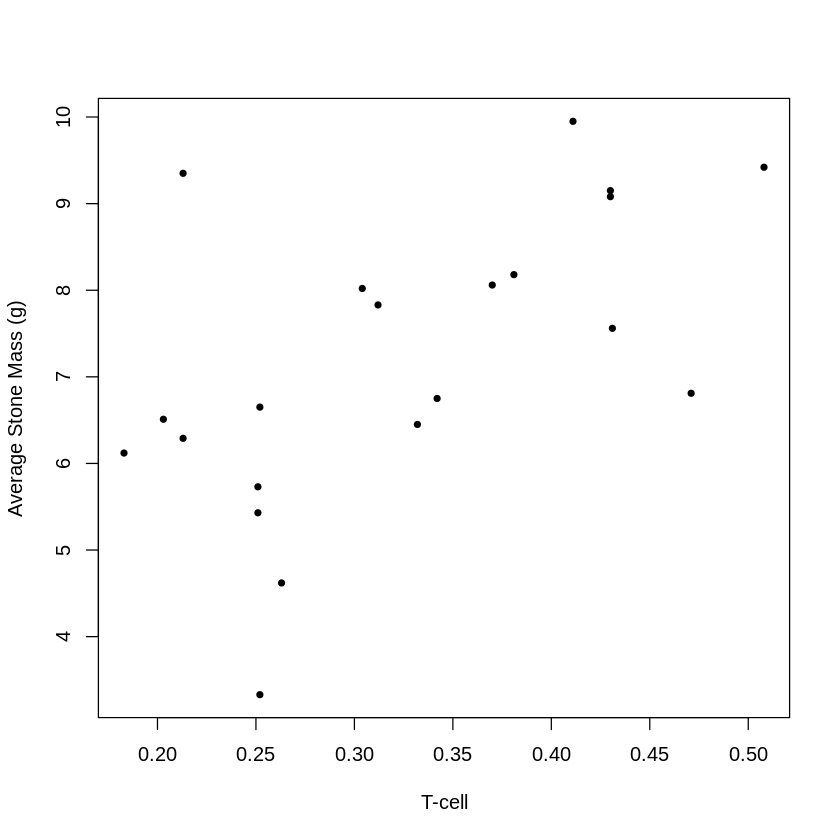

In [ ]:
plot(ex0727$Tcell, ex0727$Mass, xlab = "T-cell", ylab = "Average Stone Mass (g)", pch = 20, cex = 1)

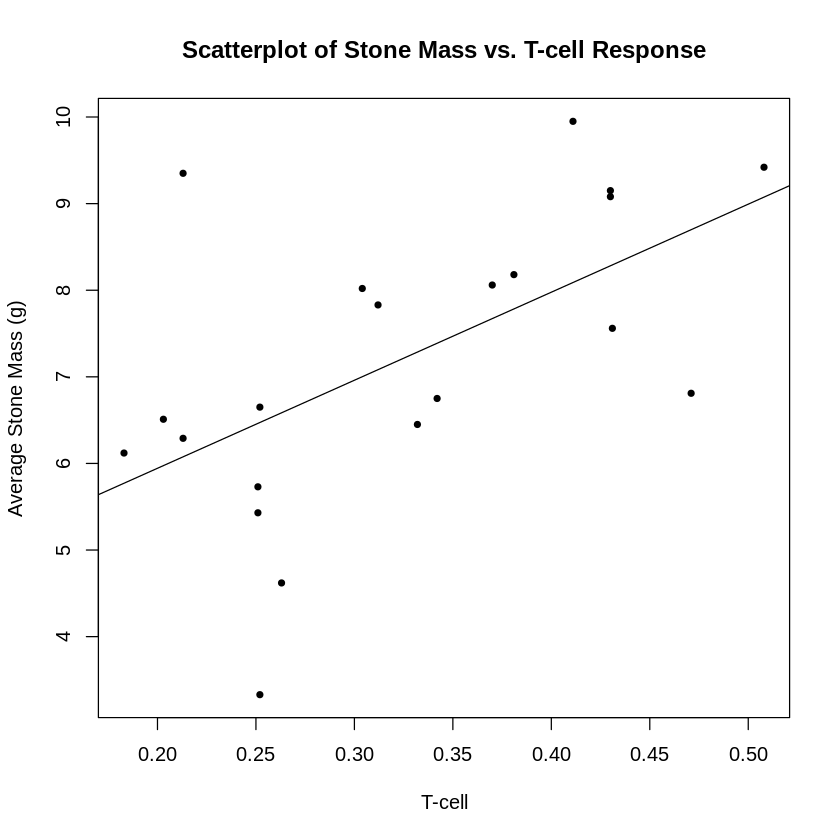

In [ ]:
plot(ex0727$Tcell, ex0727$Mass, xlab = "T-cell", ylab = "Average Stone Mass (g)", pch = 20, cex = 1, main = "Scatterplot of Stone Mass vs. T-cell Response")

abline(lm(ex0727$Mass ~ ex0727$Tcell))

The scatterplot of average stone mass versus T-cell response shows a positive linear trend. As T-cell response increases, the average mass of stones carried by the birds also tends to increase. The relationship appears approximately linear, and there are no extreme outliers that would strongly influence the model. A regression line was added to the scatterplot to illustrate the relationship between the variables. Overall, the plot suggests a moderate positive association between immune response and stone mass.

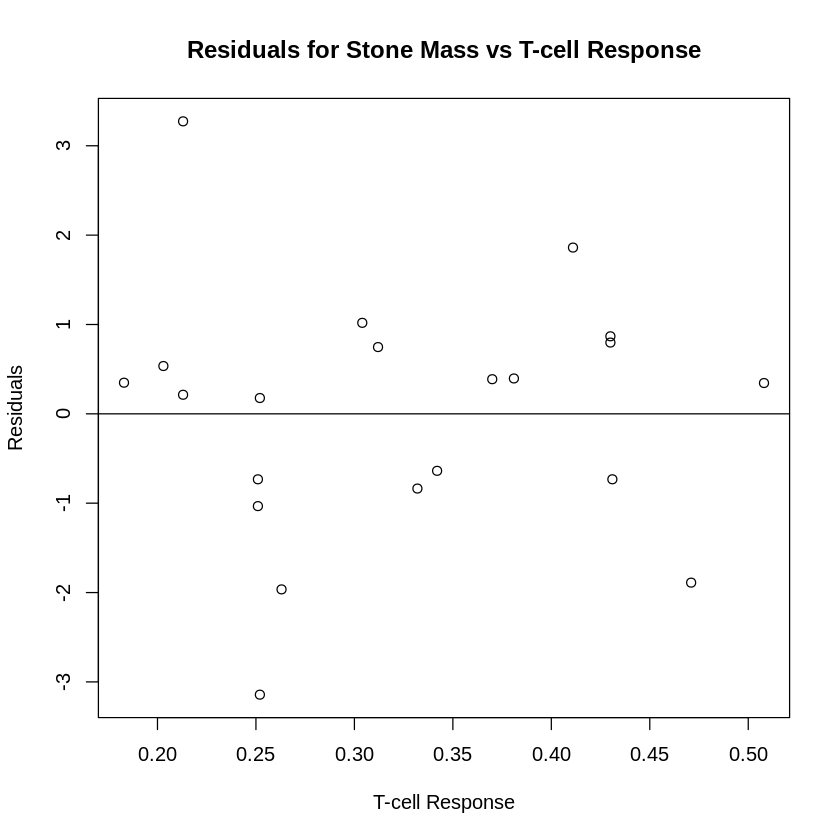

In [ ]:
model_mass_tcell <- lm(ex0727$Mass ~ ex0727$Tcell)
plot(ex0727$Tcell, resid(model_mass_tcell),
     ylab = "Residuals",
     xlab = "T-cell Response",
     main = "Residuals for Stone Mass vs T-cell Response")
abline(h = 0)

A residual plot of stone mass versus T-cell response shows no clear pattern and the spread of the residuals appears roughly constant across the range of T-cell response values. This suggests that the equal variance assumption is reasonably satisfied.

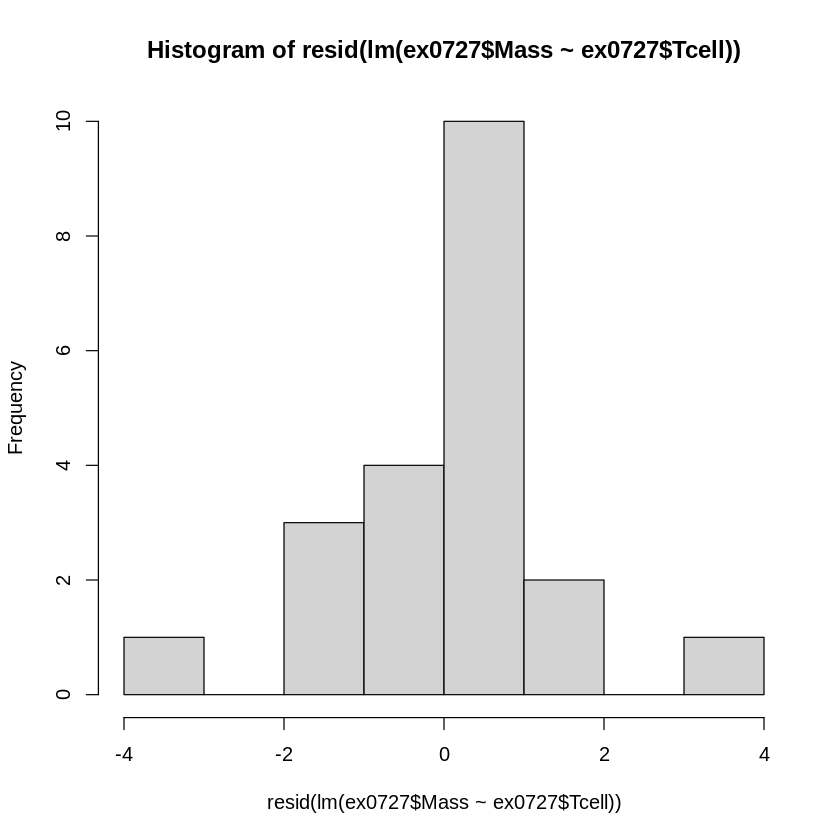

In [ ]:
hist(resid(lm(ex0727$Mass ~ ex0727$Tcell)))

#Assumptions

#Independent
Each observation corresponds to a different male black wheatear. Assuming the birds were sampled independently and measurements were taken once per individual, the independence assumption appears reasonable. However, because the study is observational and details of sampling are limited, independence cannot be fully verified.

#Normality

In [ ]:
shapiro.test(resid(model_mass_tcell))


	Shapiro-Wilk normality test

data:  resid(model_mass_tcell)
W = 0.95729, p-value = 0.4633


With a null hypothesis of normality and a p-value of 0.4633, we fail to reject the null hypothesis and conclude that this data is normal.

#Equal Variance

In [ ]:
install.packages("lawstat")
library(lawstat)

levene.test(resid(model_mass_tcell), group = cut(ex0727$Tcell, breaks = 3, include.lowest = TRUE), location = "median")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Kendall’, ‘mvtnorm’, ‘Rdpack’





	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  resid(model_mass_tcell)
Test Statistic = 0.85829, p-value = 0.4405


With a null hypothesis of equal variance and a p-value of 0.4633, we fail to reject the null hypothesis and conclude that the data has an equal variance. We can do linear regression!

#Statistical Conclusion
discuss the p-values/confidence intervals and conclusions of that statistical analysis and the methods you used (be sure to address the strength of your conclusions)

In [ ]:
# Fit the linear regression model
linear_model <- lm(ex0727$Mass ~ ex0727$Tcell)

# Display the summary of the model
summary(linear_model)


Call:
lm(formula = ex0727$Mass ~ ex0727$Tcell)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.1429 -0.7327  0.3448  0.7472  3.2736 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)     3.911      1.112   3.517  0.00230 **
ex0727$Tcell   10.165      3.296   3.084  0.00611 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.426 on 19 degrees of freedom
Multiple R-squared:  0.3336,	Adjusted R-squared:  0.2986 
F-statistic: 9.513 on 1 and 19 DF,  p-value: 0.006105


With a p-value of 0.00230 for the intercept, we reject the null hypothesis of the intercept being 0. Meaning: the intercept is not 0. Further, with a p-value of 0.00611, we can reject the null hypothesis of the slope being equal to 0. There is statistically significant evidence that T-cell response is associated with the average mass of stones carried. There is convincing evidence that neither the intercept nor the slope is 0.

#Scope of Inference
The data was collected through observation rather than through a controlled experiment, this study is classified as an observational study. As a result, the analysis can identify associations between immune response and stone mass but cannot establish a causal relationship.

The conclusions from this analysis therefore apply only to male black wheatears similar to those included in the study, and generalization to a broader population should be made cautiously unless the sampled birds are representative of the larger population. The statistical analysis produced a statistically significant positive association between T-cell response and stone mass, suggesting that males with stronger immune responses tend to carry heavier stones.

While this provides evidence supporting the hypothesis that stone carrying behavior may signal health status, the observational nature of the data means that other unmeasured factors could also influence the relationship. Overall, the evidence is convincing and supports the proposed biological theory, though it does not definitively establish causation.